A/B Testing

Its a tool that allows you to test two or more different ideas against each other in the real world, and to see which one empirically performs better.

In the real world, there is no guessing. You get to know which idea is better. At its core, it is one of the only statistically sound ways to establish causal relationships.

It works by exposing unique randomly assigned groups of users to each of the ideas, then observing these users by measuing how they behave, untangle the impact of each of the ideas ultiamtely determining which is best.



Datasets include:
Dataset 1: User Demographics ('customer_demographics.csv')
uid, reg_date, devices, gender, country, age

Dataset 2: User actions ('customer_subscriptions.csv')
uid, lapse_date, subscription_date, price


KPI:

1. Conversion Rate:
Percentage of users who subscribe after the free trial
Interval: Which time interval should be used to get KPI conversion? One month? One week? Immediately?

Choosing a KPI
1. Stability over time
2. Importance across different user groups
3. Correlation with other busines factors 



In [47]:
#importing data
import pandas as pd

customer_demographic = pd.read_csv('customer_demographics.csv')
print(customer_demographic.head())

customer_subscription = pd.read_csv('customer_subscriptions.csv')
print(customer_subscription.head())

        uid   reg_date   device gender country  age
0  10000000  4/12/2016  Android      M      UK   42
1  10000001  3/11/2017  Android      M     UAE   24
2  10000002  9/27/2016      iOS      F     PAK   55
3  10000003  4/16/2016  Android      M     USA   24
4  10000004  3/12/2016  Android      F     BRA   68
        uid  lapse_date subscription_date  price
0  10000000  2016-09-21        2016-10-14     99
1  10000001  2016-09-29        2016-10-02    499
2  10000002  2016-10-15        2016-10-21    499
3  10000003  2018-02-18        2018-02-18    499
4  10000004  2016-03-03        2016-03-13     99


In [48]:
#joining the datapframes together
sub_data_demo = customer_demographic.merge(
    customer_subscription,
    how = 'inner',
    on = ['uid']
)

sub_data_demo.head()

,uid,reg_date,device,gender,country,age,lapse_date,subscription_date,price
0,10000000,4/12/2016,Android,M,UK,42,2016-09-21,2016-10-14,99
1,10000001,3/11/2017,Android,M,UAE,24,2016-09-29,2016-10-02,499
2,10000002,9/27/2016,iOS,F,PAK,55,2016-10-15,2016-10-21,499
3,10000003,4/16/2016,Android,M,USA,24,2018-02-18,2018-02-18,499
4,10000004,3/12/2016,Android,F,BRA,68,2016-03-03,2016-03-13,99


In [49]:
#exploring KPIs
sub_data_grp = sub_data_demo.groupby(by = ['country', 'device'],
                                     axis=0,
                                     as_index=False)
sub_data_grp
sub_data_grp.price.agg(['mean', 'median'])

#OR

sub_data_grp.agg({'price': ['mean','min','max'],
                  'age': ['mean', 'min', 'max']
                #   'subscription_start_date': ['mean', 'min', 'max']
                  })


country   device       price                 age        
                           mean min  max       mean min max
0      BRA  Android  181.692214   0  499  43.614355  18  79
1      BRA      iOS  183.149206   0  499  44.179365  18  79
2      IND  Android  171.043742   0  499  44.494532  18  79
3      IND      iOS  176.821530   0  499  43.977337  18  78
4      PAK  Android  179.667098   0  499  42.804404  18  79
5      PAK      iOS  190.107981   0  499  44.165884  18  78
6      TUR  Android  180.245358   0  499  43.377984  18  77
7      TUR      iOS  189.012539   0  499  44.144201  18  79
8      UAE  Android  177.266033   0  499  42.591449  18  79
9      UAE      iOS  176.691680   0  499  43.836868  18  79
10      UK  Android  172.574271   0  499  42.251989  18  78
11      UK      iOS  184.233766   0  499  42.826299  18  78
12     USA  Android  178.683995   0  499  43.253078  18  78
13     USA      iOS  177.418182   0  499  44.287879  18  77

In [64]:
#Conversion Rate: Maximum Subscription End Date

from datetime import datetime, timedelta

current_date = pd.to_datetime('2018-03-17')

sub_data_demo['lapse_date'] = pd.to_datetime(
    sub_data_demo['lapse_date'],
    errors='coerce'
)

sub_data_demo['subscription_date'] = pd.to_datetime(
    sub_data_demo['subscription_date'],
    errors='coerce'
)
print(sub_data_demo['lapse_date'].max())


#latest lapse date: a week before today
max_lapse_date = current_date - timedelta(days=7)
print(current_date)
print(max_lapse_date)

#restrict to users lapsed before max_lapse_date
conv_sub_data = sub_data_demo[(sub_data_demo.lapse_date < max_lapse_date)]

#count the users remaining in our daata

total_users_count = conv_sub_data.price.count()
print(total_users_count)
# print(conv_sub_data)


2018-03-17 00:00:00
2018-03-17 00:00:00
2018-03-10 00:00:00
9875


In [66]:
#KPI calculation: restrict subscription date

max_sub_date = conv_sub_data.lapse_date + timedelta(days=7)
print(max_sub_date)
#filterr the users with non-zero subscription price
#who subscribed before max_sub_date

total_subs = conv_sub_data[
    (conv_sub_data.price > 0) &
    (conv_sub_data.subscription_date <= max_sub_date)
]
# total_subs

total_subs_count = total_subs.price.count()
print(total_subs_count)

#calcualte the conversion rate with our previous values
conversion_rate = total_subs_count/total_users_count
print(conversion_rate)


0      2016-09-28
1      2016-10-06
2      2016-10-22
3      2018-02-25
4      2016-03-10
          ...    
9995   2017-04-03
9996   2016-02-10
9997   2017-07-12
9998   2017-07-11
9999   2017-07-12
Name: lapse_date, Length: 9875, dtype: datetime64[ns]
1632
0.16526582278481014


In [67]:
import numpy as np 
#create a copy of our dataframe
conv_sub_data = conv_sub_data.copy()

#keep users who lapsed prior to the last 14 days (2 weeks)
max_lapse_date = current_date - timedelta(days=14)
conv_sub_data = sub_data_demo[
    (sub_data_demo.lapse_date <= max_lapse_date)
]

#sub time: How long it took a user to subscribe
sub_time = np.where(
    conv_sub_data.subscription_date.notnull(),
    (conv_sub_data.subscription_date - conv_sub_data.lapse_date).dt.days,
    pd.NaT
)

conv_sub_data['sub_time'] = sub_time
conv_sub_data

<ipython-input-67-d6eb9e6d0f3b>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  conv_sub_data['sub_time'] = sub_time


,uid,reg_date,device,gender,country,age,lapse_date,subscription_date,price,sub_time
0,10000000,4/12/2016,Android,M,UK,42,2016-09-21,2016-10-14,99,23.0
1,10000001,3/11/2017,Android,M,UAE,24,2016-09-29,2016-10-02,499,3.0
2,10000002,9/27/2016,iOS,F,PAK,55,2016-10-15,2016-10-21,499,6.0
3,10000003,4/16/2016,Android,M,USA,24,2018-02-18,2018-02-18,499,0.0
4,10000004,3/12/2016,Android,F,BRA,68,2016-03-03,2016-03-13,99,10.0
...,...,...,...,...,...,...,...,...,...,...
9995,10009995,12/24/2016,iOS,F,BRA,61,2017-03-27,2017-04-09,199,13.0
9996,10009996,12/6/2017,Android,M,IND,68,2016-02-03,2016-02-19,99,16.0
9997,10009997,2/25/2018,Android,M,UK,56,2017-07-05,NaT,0,NaT
9998,10009998,11/19/2016,iOS,M,PAK,40,2017-07-04,2017-07-19,499,15.0


In [71]:
def gcr7(sub_time):
    """
    7-day conversion rate.
    Counts users who subscribed within 7 days of lapse date.
    """
    return (sub_time <= 7).mean()

def gcr14(sub_time):
    """
    14-day conversion rate.
    Counts users who subscribed within 14 days of lapse date.
    """
    return (sub_time <= 14).mean()


purchase_cohorts = conv_sub_data.groupby(by=['gender', 'device'],
                                         as_index=False)

purchase_cohorts.agg({'sub_time': [gcr7,gcr14]})

#how to choose KPI Metric?
##infinite many potential KPis
##how long does it take to determine
##leverage exploratory data analysis




gender   device  sub_time          
                       gcr7     gcr14
0      F  Android  0.162574  0.308408
1      F      iOS  0.163440  0.308870
2      M  Android  0.163220  0.314993
3      M      iOS  0.173218  0.315356

Next:
1. How does this KPI evolve over time?
2. See how changes can imapct different group differently

In [77]:
#Exploratory Data Analyst

conv_base = conv_sub_data[(conv_sub_data.sub_time.notnull()) | \
                          (conv_sub_data.sub_time > 7)]

# conv_base
total_users = len(conv_base)
print(total_users)
total_subs = np.where(conv_sub_data.sub_time.notnull() & \
                      (conv_base.sub_time <= 14), 1, 0)

total_subs = sum(total_subs)
print(total_subs)

conversion_rate = total_subs / total_users
print(conversion_rate)


6365
3058
0.4804399057344855


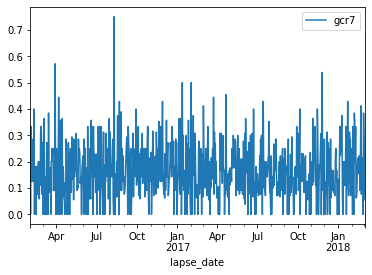

In [84]:
#creating time-series graphs with matplotlib
import matplotlib.pyplot as plt
conv_sub_data

#find the conversion rate for each daily cohort
conversion_data = conv_sub_data.groupby(
    by=['lapse_date'], as_index=False
).agg({'sub_time': [gcr7]})


conversion_data.head()

conversion_data['lapse_date'] = pd.to_datetime(
    conversion_data.lapse_date
)

conversion_data.plot(x='lapse_date', y='sub_time')
plt.show()


c:\Python\Python39\lib\site-packages\pandas\core\generic.py:4153: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  obj = obj._drop_axis(labels, axis, level=level, errors=errors)


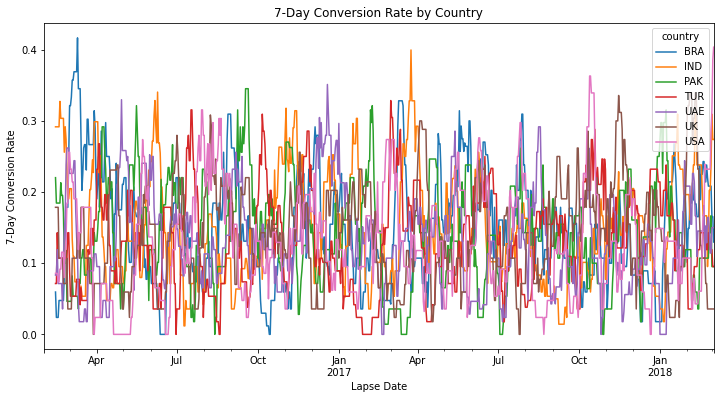

In [103]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by lapse_date and country
conversion_data = conv_sub_data.groupby(
    by=['lapse_date', 'country'],
    as_index=False
).agg({
    'sub_time': [gcr7]
})

# Convert lapse_date to datetime
conversion_data['lapse_date'] = pd.to_datetime(
    conversion_data['lapse_date']
)

# Create pivot table
reformatted_cntry_data = pd.pivot_table(
    conversion_data,
    values='sub_time',
    columns='country',
    index='lapse_date',
    fill_value=0
)

# Fix multi-level columns
reformatted_cntry_data.columns = (
    reformatted_cntry_data.columns.get_level_values(1)
)

# Apply 14-day rolling average to smooth the lines
smooth_data = reformatted_cntry_data.rolling(14).mean()

# Plot country trends
smooth_data.plot(
    figsize=(12, 6)
)

plt.title('7-Day Conversion Rate by Country')
plt.xlabel('Lapse Date')
plt.ylabel('7-Day Conversion Rate')
plt.show()

In [105]:
#further techniques for uncovering trends
conv_sub_data.head()

,uid,reg_date,device,gender,country,age,lapse_date,subscription_date,price,sub_time
0,10000000,4/12/2016,Android,M,UK,42,2016-09-21,2016-10-14,99,23.0
1,10000001,3/11/2017,Android,M,UAE,24,2016-09-29,2016-10-02,499,3.0
2,10000002,9/27/2016,iOS,F,PAK,55,2016-10-15,2016-10-21,499,6.0
3,10000003,4/16/2016,Android,M,USA,24,2018-02-18,2018-02-18,499,0.0
4,10000004,3/12/2016,Android,F,BRA,68,2016-03-03,2016-03-13,99,10.0


country     BRA  IND       PAK  TUR       UAE   UK   USA    USA_7d   USA_28d  \
lapse_date                                                                     
2016-02-01  0.5  0.0  0.500000  0.0  0.000000  0.0  0.00       NaN       NaN   
2016-02-02  0.0  0.0  0.000000  0.0  0.000000  0.0  0.00       NaN       NaN   
2016-02-03  0.0  0.0  0.000000  1.0  0.666667  0.0  0.50       NaN       NaN   
2016-02-04  0.0  0.0  0.000000  0.0  0.000000  1.0  0.00       NaN       NaN   
2016-02-05  0.0  0.5  0.000000  0.0  0.000000  0.0  0.00       NaN       NaN   
...         ...  ...       ...  ...       ...  ...   ...       ...       ...   
2018-02-27  0.0  0.0  0.000000  0.0  0.000000  0.0  0.00  0.214286  0.137500   
2018-02-28  0.0  0.5  0.333333  0.0  0.000000  0.5  1.00  0.214286  0.173214   
2018-03-01  0.4  1.0  0.000000  0.0  0.500000  0.0  0.40  0.200000  0.187500   
2018-03-02  0.0  0.0  0.000000  0.0  0.000000  0.0  1.00  0.342857  0.223214   
2018-03-03  0.0  0.0  0.000000  0.0  0.0

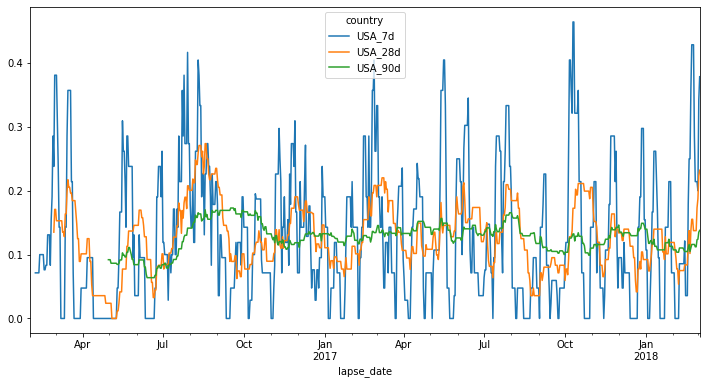

In [107]:
rolling_conversion = reformatted_cntry_data.copy()

rolling_conversion['USA_7d'] = (
    rolling_conversion['USA']
    .rolling(window=7)
    .mean()
)

rolling_conversion['USA_28d'] = (
    rolling_conversion['USA']
    .rolling(window=28)
    .mean()
)

rolling_conversion['USA_90d'] = (
    rolling_conversion['USA']
    .rolling(window=90)
    .mean()
)

print(rolling_conversion)

rolling_conversion[
    ['USA_7d', 'USA_28d', 'USA_90d']
].plot(figsize=(12,6))
plt.show()

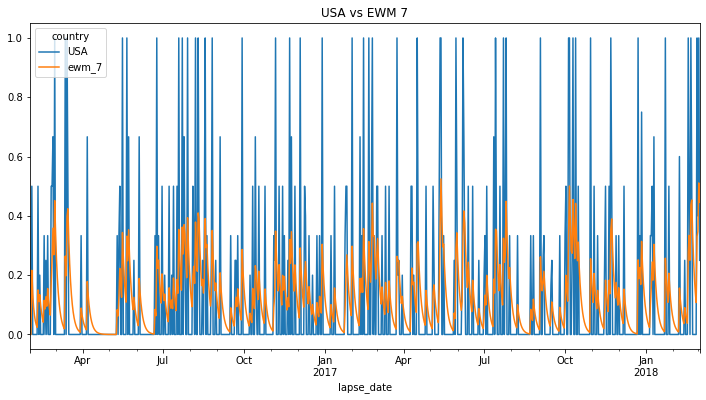

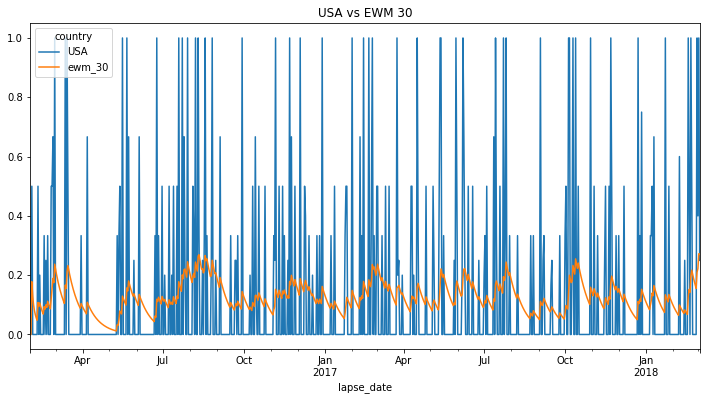

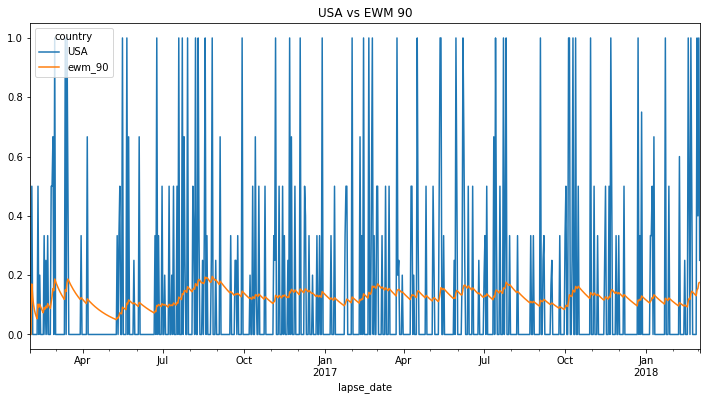

In [112]:
#using exponentials to give weightage to recent data 

exponential_conversion = reformatted_cntry_data.copy()
# ewm_7 = reformatted_cntry_data.ewm(span = 7).mean()
exponential_conversion['ewm_7'] = (
    exponential_conversion['USA'].ewm(span=7).mean()
)
# exponential_conversion

exponential_conversion['ewm_30'] = (
  exponential_conversion['USA'].ewm(span=30).mean()
)

exponential_conversion['ewm_90'] = (
    exponential_conversion['USA'].ewm(span=90).mean()
)
exponential_conversion['raw'] = exponential_conversion['USA']

exponential_conversion[['USA','ewm_7']].plot(figsize=(12,6))
plt.title('USA vs EWM 7')
plt.show()

# EWM 30
exponential_conversion[['USA','ewm_30']].plot(figsize=(12,6))
plt.title('USA vs EWM 30')
plt.show()

# EWM 90
exponential_conversion[['USA','ewm_90']].plot(figsize=(12,6))
plt.title('USA vs EWM 90')
plt.show()